## 🧠 What is a CNN? (Big Idea — No Math Panic)

A **Convolutional Neural Network (CNN)** is a type of neural network designed **specifically for image data**.

Instead of treating an image as one long list of numbers, CNNs work more like the **human visual system**.

### 🔍 What Makes CNNs Special?
CNNs:
- Look at **small patches** of an image at a time
- Learn features in stages:
  - **Edges → Shapes → Objects**
- **Preserve spatial structure** (important for images)

This makes CNNs very powerful for tasks like image classification, object detection, and face recognition.



## 🧩 Core CNN Building Blocks (Concept First)

### 1️⃣ Convolution Layer
- Slides a small filter (called a **kernel**) over the image
- Detects basic patterns like:
  - Edges
  - Curves
  - Textures

🧠 **Think:**  
> “Is there a vertical line here?”  
> “Is there an edge in this region?”



### 2️⃣ ReLU Activation
- Introduces **non-linearity**
- Keeps positive values
- Turns negative values into zero

🧠 **Think:**  
> “Keep strong signals, ignore weak ones”



### 3️⃣ Pooling Layer (Max Pooling)
- Reduces image size (**downsampling**)
- Keeps the most important features
- Reduces computation and overfitting

🧠 **Think:**  
> “Summarize without losing meaning”


### 4️⃣ Fully Connected Layer
- Comes **after feature extraction**
- Uses learned features to make the final decision

🧠 **Think:**  
> “Based on what I see, what is this?”



## 🧠 Example 1: CNN on Image Data (MNIST)

### 🎯 Goal
The goal of this example is to build a **Convolutional Neural Network (CNN)** to classify **handwritten digit images** into **10 classes (0–9)**.



### 📦 MNIST Dataset Overview
- Contains **70,000 grayscale images**
- Image size: **28 × 28 × 1**
- **60,000 training images**
- **10,000 test images**
- Widely used as a **beginner-friendly dataset** for image classification

---

### 🔢 Digit Classes
The dataset includes the following handwritten digits:

**0, 1, 2, 3, 4, 5, 6, 7, 8, 9**

---

### 🧩 Why Use CNN for MNIST?
- CNNs capture **spatial patterns** in images
- Automatically learn features like:
  - Edges
  - Curves
  - Strokes
- Perform better than traditional fully connected networks on image data

---

### 🏗️ Typical CNN Pipeline
1. **Convolution Layer** – Detects edges and shapes  
2. **ReLU Activation** – Adds non-linearity  
3. **Pooling Layer** – Reduces image size  
4. **Fully Connected Layer** – Classifies digits  
5. **Softmax Output** – Predicts digit probabilities  

---

### 📌 Applications
- Digit recognition systems
- Postal code reading
- Bank cheque processing
- Optical Character Recognition (OCR)

---

### ✅ Outcome
After training, the CNN can accurately classify handwritten digits from **0 to 9** with high accuracy.


In [ ]:
pip install tensorflow matplotlib

**📦 Step 1: Import libraries**

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

**🖼 Step 2: Load Image Dataset**

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Visualize the Data**

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

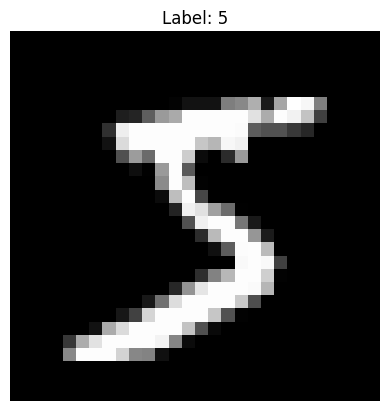

In [3]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")

**🔧 Step 3: Preprocess the Images**

Normalize pixel values to 0–1

CNN expects 4D input:
(samples, height, width, channels)

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

**🏗 Step 4: Build the CNN**

Conv2D(32) → learns 32 different filters

MaxPooling → shrinks image, keeps important features

Conv2D(64) → deeper features (shapes, parts)

Flatten → turns feature maps into a vector

Dense(10) → one neuron per digit (0–9)

In [5]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Step 5: Compile the Model**

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**🚀 Step 6: Train the CNN**

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.8973 - loss: 0.3387 - val_accuracy: 0.9853 - val_loss: 0.0535
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - accuracy: 0.9839 - loss: 0.0511 - val_accuracy: 0.9897 - val_loss: 0.0381
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9895 - loss: 0.0335 - val_accuracy: 0.9895 - val_loss: 0.0410
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9919 - loss: 0.0236 - val_accuracy: 0.9898 - val_loss: 0.0369
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9943 - loss: 0.0170 - val_accuracy: 0.9910 - val_loss: 0.0306


**Step 7: Evaluate on Test Data**

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9870 - loss: 0.0425
Test accuracy: 0.9908999800682068


**🔮 Step 8: Make Predictions**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

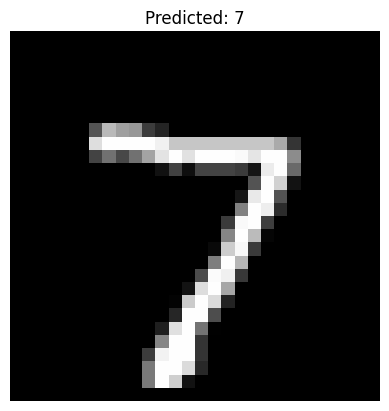

In [9]:
prediction = model.predict(X_test[:1])
predicted_label = prediction.argmax()

plt.imshow(X_test[0].reshape(28,28), cmap="gray")
plt.title(f"Predicted: {predicted_label}")
plt.axis("off")

## 🧠 Example 2: CNN on Fashion-MNIST

### 🎯 Task
The objective of this example is to build a **Convolutional Neural Network (CNN)** to classify images from the **Fashion-MNIST dataset** into **10 different clothing categories**.


### 📦 Fashion-MNIST Dataset Overview
- Contains **70,000 grayscale images**
- Image size: **28 × 28 × 1**
- **60,000 training images**
- **10,000 test images**
- Designed as a drop-in replacement for the MNIST digit dataset


### 🏷️ Clothing Categories
The dataset includes the following 10 classes:

1. 👕 T-shirt / Top  
2. 👖 Trouser  
3. 🧥 Pullover  
4. 👗 Dress  
5. 🧥 Coat  
6. 👡 Sandal  
7. 👔 Shirt  
8. 👟 Sneaker  
9. 👜 Bag  
10. 👢 Ankle boot  



### 🏗️ Typical CNN Architecture (High-Level)
1. **Convolutional Layer** – Feature extraction  
2. **ReLU Activation** – Adds non-linearity  
3. **Max Pooling** – Reduces spatial dimensions  
4. **Fully Connected Layers** – Classification  
5. **Softmax Output Layer** – Predicts class probabilities  



### Outcome
After training, the CNN can accurately classify fashion items into one of the **10 clothing categories**.


**📦 Step 1: Import libraries**

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

**🖼 Step 2: Load the Dataset**

In [11]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Visualize a Few Samples**

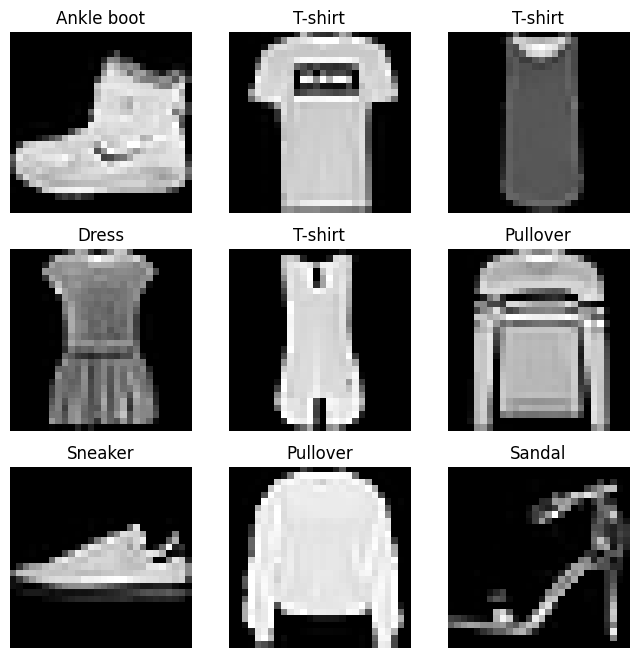

In [12]:
class_names = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.show()

**🔧 Step 3: Preprocessing**

In [13]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

**🏗 Step 4: Build the CNN**

In [14]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

##  How CNN Learns Features (Layer-wise Intuition)

CNNs learn image features **progressively**, from simple patterns to complex concepts.


### 🔹 Early Layers
- Detect **edges, corners, and textures**
- Capture low-level features like:
  - Fabric patterns
  - Outlines
  - Simple shapes

*Example:* Detecting straight lines or texture on clothing



### 🔹 Middle Layers
- Combine low-level features into **meaningful parts**
- Learn object components such as:
  - Shoe soles
  - Sleeves
  - Collars
  - Buttons

*Example:* Recognizing parts of a sneaker or shirt


### 🔹 Deeper Layers
- Understand **complete objects**
- Combine parts to form:
  - Shoes
  - Dresses
  - Bags


### 🔹 Dense (Fully Connected) Layer
- Performs **decision making**
- Uses extracted features to predict the final class




**Step 5: Compile the Model**

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**🚀 Step 6: Train**

In [16]:
model.fit(
    X_train,
    y_train,
    epochs=8,
    validation_split=0.1
)

Epoch 1/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.7574 - loss: 0.6625 - val_accuracy: 0.8733 - val_loss: 0.3402
Epoch 2/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.8862 - loss: 0.3099 - val_accuracy: 0.8967 - val_loss: 0.2841
Epoch 3/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9036 - loss: 0.2578 - val_accuracy: 0.8948 - val_loss: 0.2841
Epoch 4/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9163 - loss: 0.2275 - val_accuracy: 0.9075 - val_loss: 0.2583
Epoch 5/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.9264 - loss: 0.1952 - val_accuracy: 0.9093 - val_loss: 0.2393
Epoch 6/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9354 - loss: 0.1728 - val_accuracy: 0.9168 - val_loss: 0.2474
Epoch 7/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.9432 - loss: 0.1515 - val_accuracy: 0.9117 - val_loss: 0.2537
Epoch 8/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9485 - loss: 0

**Step 7: Evaluate**

In [17]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9044 - loss: 0.2916
Test accuracy: 0.9060999751091003


**🔮 Step 8: Prediction Demo**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

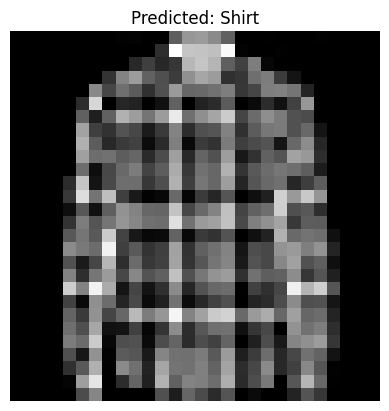

In [18]:
import numpy as np

index = 7
prediction = model.predict(X_test[index:index+1])
predicted_class = np.argmax(prediction)

plt.imshow(X_test[index].reshape(28,28), cmap="gray")
plt.title(f"Predicted: {class_names[predicted_class]}")
plt.axis("off")

## ⚡ Quick Teaching Comparison (Great Slide Moment)

| Dataset          | Why CNNs Help |
|------------------|---------------|
| **MNIST**        | Simple shapes and strokes; CNNs easily learn edges and curves |
| **Fashion-MNIST**| Real-world objects with subtle differences; CNNs capture textures, shapes, and fine details |

---


- **MNIST** shows how CNNs learn **basic visual patterns**
- **Fashion-MNIST** demonstrates CNNs handling **more complex, real-world features**
- Highlights why CNNs outperform traditional neural networks on image data
